# Cobertura y costo de la CBA actual: urbana y rural

**Pregunta:** ¿cómo se comparan las cantidades y proporciones publicadas de la CBA con las referencias nutricionales de distintos sujetos?

Se presentan dos escenarios: **ración actual per cápita**, igual para todos los sujetos dentro de cada área, y **ajustada a energía**, que multiplica todos los alimentos por un mismo factor. El segundo conserva las proporciones y permite comparar cuánto costaría alcanzar la referencia energética de cada sujeto. No se ejecuta una optimización.

La CBA caracteriza patrones de gasto y consumo, no una dieta normativa individual. La metodología regional considera 66 productos urbanos y 60 rurales. [Fuente: INE, Canasta Básica Alimentaria](https://www.ine.gob.gt/canasta-basica-alimentaria/).

**Alcance:** comparación exploratoria contra el evaluador implementado en este proyecto. Los resultados por sujeto no estiman prevalencias ni constituyen un diagnóstico nutricional.

In [17]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / 'src' / 'canasta_inteligente').is_dir())
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from canasta_inteligente.application.cba_pipeline import load_catalog_pickle
from canasta_inteligente.application.analisis_cobertura_cba import cargar_canastas, analizar_cobertura
from canasta_inteligente.domain.persona import Persona

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 100)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
COLORES = {'urbana': '#2563a6', 'rural': '#c16a24'}

## 1. Parámetros editables

`PERIODO=None` selecciona el **último mes común de los dos Excel locales**, no el último precio de cada alimento. Para fijar un mes, usa `(2026, 8)`. Se conserva el costo diario publicado y se multiplica por `DIAS`; no se divide nuevamente por el tamaño promedio del hogar.

Se usa la energía publicada por INE para la cobertura energética completa. Los demás nutrientes se calculan con las equivalencias INCAP del catálogo, ajustados por fracción comestible. Ambas estimaciones de energía se muestran por separado para auditar sus diferencias. La fracción comestible es un supuesto editable: revisa si los gramos originales representan compra o parte comestible antes de cambiarlo.

La tolerancia de ±10 % para energía es una **convención de este análisis**, no un umbral clínico. El hierro se evalúa por defecto con baja biodisponibilidad; el zinc conserva la misma hipótesis del modelo. Las referencias y máximos provienen del evaluador existente; algunos máximos tienen condiciones de aplicación por forma química o suplementación que requieren revisión antes de una interpretación clínica.

In [18]:
PERIODO = None
DIAS = 30
TOLERANCIA_ENERGIA = 0.10
HIERRO = 'baja_biodisponibilidad'  # también media_biodisponibilidad / alta_biodisponibilidad
APLICAR_FRACCION_COMESTIBLE = True
EXPORTAR = True
CATALOGO = PROJECT_ROOT / 'data' / 'processed' / 'cba_catalog.pkl'
HISTORICOS = PROJECT_ROOT / 'data' / 'raw' / 'ine' / 'cba_historicos'


EQUIVALENCIAS = {}
catalog = load_catalog_pickle(CATALOGO)
canastas = cargar_canastas(HISTORICOS, catalog, PERIODO, EQUIVALENCIAS)
periodo_analizado = canastas['periodo'].iloc[0]
salida = PROJECT_ROOT / 'data' / 'processed' / 'analisis_cobertura_cba' / periodo_analizado
if EXPORTAR:
    salida.mkdir(parents=True, exist_ok=True)
print(f'Período común analizado: {periodo_analizado} | Costos para {DIAS} días')

Período común analizado: 2026-08 | Costos para 30 días


## 2. Sujetos y justificación

Son **casos ilustrativos**, seleccionados para contrastar necesidades a lo largo de la vida. Las edades, tallas y pesos son supuestos editables; no son promedios nacionales ni una muestra representativa. Todos los sujetos se evalúan contra ambas áreas: no se asigna automáticamente una ocupación o un nivel de actividad a la población rural.

| Perfil | Razón de inclusión |
|---|---|
| Preescolar y escolar | Examinar cómo cambia la comparación al pasar de una ración per cápita a referencias infantiles; resultados energéticos exploratorios por la limitación indicada abajo. |
| Adolescente mujer y hombre | Contrastar las referencias por edad y sexo durante la adolescencia. |
| Mujer adulta | Referencia de comparación para embarazo y lactancia. |
| Hombre adulto, actividad baja y alta | Comparación controlada con igual edad, peso y talla; aísla el efecto del nivel de actividad. |
| Mujer adulta mayor | Incluir la etapa de vejez en la comparación. |
| Embarazo y lactancia | Examinar los incrementos específicos del modelo en estas etapas. |

La inclusión de niñez, embarazo y lactancia es pertinente al contexto alimentario guatemalteco: el INCAP ha desarrollado recomendaciones basadas en alimentos para estos grupos en el Altiplano Occidental. Esto justifica estudiar esos grupos; **no valida los valores antropométricos elegidos aquí**. [INCAP, estudio sobre niños, embarazadas y lactantes](https://bvssan.incap.int/local/D/DCE-211.pdf). Las demás elecciones son decisiones de diseño para explorar variación entre etapas y actividad, apoyadas en las distinciones del evaluador del proyecto.

Referencias del proyecto: [Recomendaciones Dietéticas Diarias del INCAP, copia local](../data/raw/incap/714732412-Recomendaciones-Dieteticas-Diarias-del-INCAP.pdf) y [evaluador implementado](../src/canasta_inteligente/nutrition/evaluation/_implementation.py).

**Limitación pediátrica comprobada:** para edades ≤10 años, el evaluador utiliza TMB sin multiplicar por actividad. Esto puede sobreestimar la cobertura energética calculada y subestimar el costo de la ración ajustada. Los resultados infantiles se conservan como exploración del código y deben revisarse antes de interpretar exceso o suficiencia reales. El marcador † identifica esos sujetos en los gráficos.

In [25]:
from dataclasses import dataclass
import numpy as np
import pandas as pd


@dataclass
class PersonaSintetica:
    edad: int
    sexo: str


@dataclass
class HogarSintetico:
    id_origen: str
    personas: list[PersonaSintetica]

    @property
    def tamanio(self):
        return len(self.personas)


class GeneradorPoblacionGT:

    def __init__(
        self,
        personas: pd.DataFrame,
        hogares: pd.DataFrame,
        hogar_id_col: str,
        edad_col: str,
        sexo_col: str,
        peso_muestral_col: str | None = None,
        seed: int | None = None,
    ):
        self.personas = personas
        self.hogares = hogares.drop_duplicates(hogar_id_col).copy()

        self.hogar_id_col = hogar_id_col
        self.edad_col = edad_col
        self.sexo_col = sexo_col
        self.peso_muestral_col = peso_muestral_col

        self.rng = np.random.default_rng(seed)

    def _probabilidades_hogares(self):

        if self.peso_muestral_col is None:
            return None

        weights = (
            self.hogares[self.peso_muestral_col]
            .astype(float)
            .to_numpy()
        )

        return weights / weights.sum()

    def generar_hogar(self) -> HogarSintetico:

        ids = self.hogares[self.hogar_id_col].to_numpy()

        hogar_id = self.rng.choice(
            ids,
            p=self._probabilidades_hogares()
        )

        miembros = self.personas[
            self.personas[self.hogar_id_col] == hogar_id
        ]

        personas = [
            PersonaSintetica(
                edad=int(row[self.edad_col]),
                sexo=row[self.sexo_col]
            )
            for _, row in miembros.iterrows()
        ]

        return HogarSintetico(
            id_origen=str(hogar_id),
            personas=personas
        )

    def generar(self, n: int):
        return [
            self.generar_hogar()
            for _ in range(n)
        ]

In [ ]:
generator = GeneradorPoblacionGT(
    personas=df_personas,
    hogares=df_hogares,
    hogar_id_col="id_hogar",
    edad_col="edad",
    sexo_col="sexo",
    peso_muestral_col="factor_expansion",
    seed=42
)

hogares = generator.generar(1000)

In [19]:
SUJETOS = [
    dict(nombre='Preescolar 3 años †', edad=3, sexo='mujer', peso=14, altura=0.96, naf='moderate'),
    dict(nombre='Escolar 8 años †', edad=8, sexo='hombre', peso=26, altura=1.27, naf='moderate'),
    dict(nombre='Adolescente mujer', edad=15, sexo='mujer', peso=48, altura=1.56, naf='moderate'),
    dict(nombre='Adolescente hombre', edad=15, sexo='hombre', peso=52, altura=1.62, naf='moderate'),
    dict(nombre='Mujer adulta', edad=30, sexo='mujer', peso=55, altura=1.55, naf='moderate'),
    dict(nombre='Hombre actividad baja', edad=30, sexo='hombre', peso=65, altura=1.68, naf='low'),
    dict(nombre='Hombre actividad alta', edad=30, sexo='hombre', peso=65, altura=1.68, naf='high'),
    dict(nombre='Mujer adulta mayor', edad=70, sexo='mujer', peso=55, altura=1.55, naf='low'),
    dict(nombre='Embarazo, mes 7', edad=28, sexo='mujer', peso=62, altura=1.55, naf='moderate',
         esta_embarazada=True, mes_de_embarazo=7, peso_preembarazo=55),
    dict(nombre='Lactancia, mes 3', edad=28, sexo='mujer', peso=58, altura=1.55, naf='moderate',
         esta_en_lactancia=True, mes_de_lactancia=3, peso_preembarazo=55, reservas_de_energia_maternales=False),
]
EXPOSICION_SOLAR_SUFICIENTE = False
personas = [Persona(**{'exposicion_solar_suficiente': EXPOSICION_SOLAR_SUFICIENTE, **p}) for p in SUJETOS]
analisis = analizar_cobertura(canastas, catalog, personas, dias=DIAS, hierro=HIERRO,
                             tolerancia_energia=TOLERANCIA_ENERGIA,
                             aplicar_fraccion_comestible=APLICAR_FRACCION_COMESTIBLE)
perfiles = analisis['perfiles']
resumen = analisis['resumen']
cobertura = analisis['cobertura']
display(perfiles.round(2))

,perfil_id,persona,edad,sexo,peso_kg,altura_m,actividad,peso_calculos_kg,energia_requerida_kcal,advertencia_modelo
0,1,Preescolar 3 años †,3,mujer,14,0.96,moderate,14,770.31,Energía = TMB sin factor de actividad; revisar referencia pediátrica
1,2,Escolar 8 años †,8,hombre,26,1.27,moderate,26,1094.66,Energía = TMB sin factor de actividad; revisar referencia pediátrica
2,3,Adolescente mujer,15,mujer,48,1.56,moderate,48,2336.31,
3,4,Adolescente hombre,15,hombre,52,1.62,moderate,52,2919.06,
4,5,Mujer adulta,30,mujer,55,1.55,moderate,55,2261.93,
5,6,Hombre actividad baja,30,hombre,65,1.68,low,65,2509.11,
6,7,Hombre actividad alta,30,hombre,65,1.68,high,65,3561.32,
7,8,Mujer adulta mayor,70,mujer,55,1.55,low,55,1794.92,
8,9,"Embarazo, mes 7",28,mujer,62,1.55,moderate,55,2752.78,
9,10,"Lactancia, mes 3",28,mujer,58,1.55,moderate,58,3030.58,


In [24]:
perfiles['energia_requerida_kcal'].mean()

np.float64(2303.0962700000005)

In [ ]:
auditoria = analisis['auditoria']
display(auditoria.round(3))
sin_equivalencia = canastas.loc[canastas['nombre_incap'].isna(),
    ['region', 'producto', 'gramos_diarios', 'costo_diario_q', 'energia_ine_kcal', 'emparejamiento']]
display(Markdown('**Productos sin composición nutricional asociada**'))
display(sin_equivalencia.round(3))
faltantes = analisis['aportes_por_alimento'].loc[lambda t: ~t['dato_disponible']]
display(Markdown('**Productos sin dato por nutriente y área**'))
display(faltantes.groupby(['nutriente', 'region']).size().unstack('region', fill_value=0))

,region,periodo,productos,gramos_diarios,costo_diario_q,energia_ine_kcal,productos_emparejados,costo_periodo_q,energia_incap_documentada_kcal
0,rural,2026-08,60,1337.471,24.472,2172.0,54,734.16,1712.279
1,urbana,2026-08,66,1759.160,31.667,2052.0,62,950.00,1943.614


**Productos sin composición nutricional asociada**

,region,producto,gramos_diarios,costo_diario_q,energia_ine_kcal,emparejamiento
50,urbana,Café molido,0.987,0.101,2.232,sin correspondencia
52,urbana,Agua purificada,494.341,3.460,0.000,sin correspondencia
61,urbana,Desayuno o cena continental (bebida y dos acompañamientos elaborados),25.712,1.511,31.452,sin correspondencia
62,urbana,"Almuerzo o cena simple (bebida, carne de pollo y acompañamiento) excluye gaseosa",68.027,4.004,83.215,sin correspondencia
68,rural,Maíz blanco,78.903,0.408,287.996,sin correspondencia
70,rural,Harina para atoles (incluye Incaparina),4.654,0.116,17.359,sin correspondencia
112,rural,Café molido,1.700,0.174,3.841,sin correspondencia
114,rural,Agua purificada,168.970,1.183,0.000,sin correspondencia
122,rural,Desayuno o cena continental (bebida y dos acompañamientos elaborados),35.996,2.115,59.993,sin correspondencia
123,rural,"Almuerzo o cena simple (bebida, carne de pollo y acompañamiento) excluye gaseosa",58.916,3.468,96.764,sin correspondencia


**Productos sin dato por nutriente y área**

region,rural,urbana
nutriente,,
ac_folico_mcg,6,4
ac_pantotenico_mg,6,4
ag_poli_g,6,4
ag_sat_g,6,4
azucares_g,6,4
calcio_mg,6,4
carbohidratos_g,6,4
cobre_mg,6,4
colesterol_mg,6,4


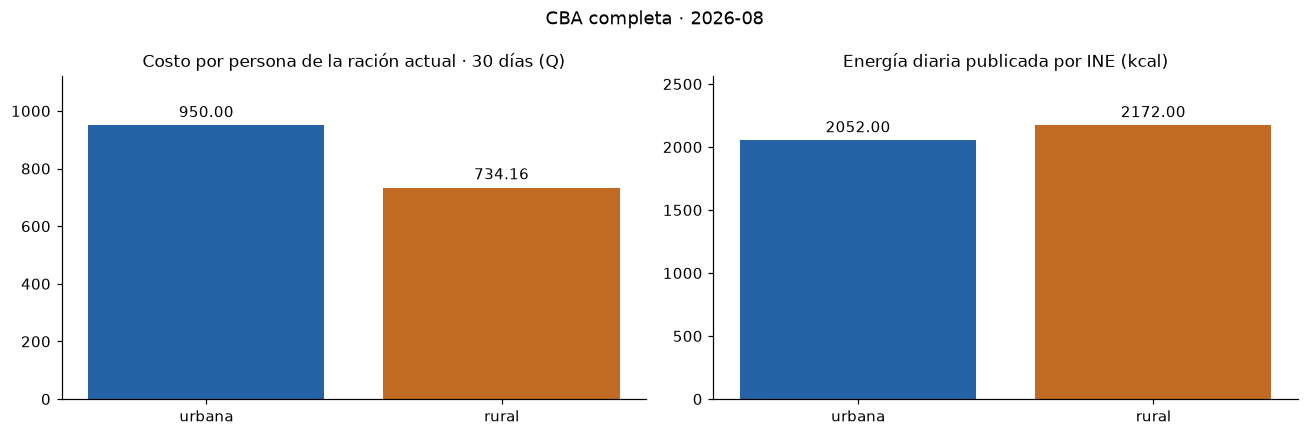

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, columna, titulo in (
    (axes[0], 'costo_periodo_q', f'Costo por persona de la ración actual · {DIAS} días (Q)'),
    (axes[1], 'energia_ine_kcal', 'Energía diaria publicada por INE (kcal)'),
):
    datos = auditoria.set_index('region')[columna].reindex(['urbana', 'rural'])
    bars = ax.bar(datos.index, datos, color=[COLORES[r] for r in datos.index])
    ax.bar_label(bars, fmt='%.2f', padding=3)
    ax.set_title(titulo, fontsize=11)
    ax.margins(y=0.18)
fig.suptitle(f'CBA completa · {periodo_analizado}')
fig.tight_layout()
if EXPORTAR:
    fig.savefig(salida / '01_canastas_actuales.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Ración actual: misma compra, cobertura distinta por sujeto

Dentro de un área, todos reciben las mismas cantidades de la CBA per cápita y, por tanto, el mismo costo. Cambia el denominador de la cobertura: el requerimiento de cada perfil. El porcentaje energético usa el total INE; para los demás nutrientes se informa la cobertura documentada.

La media de cobertura limita cada razón al 100 % para que un nutriente abundante no compense a otro. Es un resumen descriptivo, **no un porcentaje de suficiencia de la dieta ni de personas cubiertas**; se acompaña del número de datos y no concluyentes. Las coberturas por nutriente conservan valores superiores a 100 %.

,persona,region,costo_diario_q,costo_periodo_q,cobertura_energia_pct,media_cobertura_documentada_pct,metas_con_datos,metas_totales,bajo_minimo_confirmado,maximos_superados_confirmados,no_concluyentes
0,Preescolar 3 años †,rural,24.47,734.16,281.96,90.29,25,25,0,6,12
2,Preescolar 3 años †,urbana,31.67,950.00,266.39,93.22,25,25,0,7,10
4,Escolar 8 años †,rural,24.47,734.16,198.42,86.40,26,26,0,3,18
6,Escolar 8 años †,urbana,31.67,950.00,187.46,90.50,26,26,0,7,11
8,Adolescente mujer,rural,24.47,734.16,92.97,72.80,26,26,0,2,25
10,Adolescente mujer,urbana,31.67,950.00,87.83,81.00,26,26,1,3,20
12,Adolescente hombre,rural,24.47,734.16,74.41,69.32,26,26,1,2,25
14,Adolescente hombre,urbana,31.67,950.00,70.30,77.62,26,26,1,3,22
16,Mujer adulta,rural,24.47,734.16,96.02,73.69,27,27,0,2,25
18,Mujer adulta,urbana,31.67,950.00,90.72,82.67,27,27,0,3,19


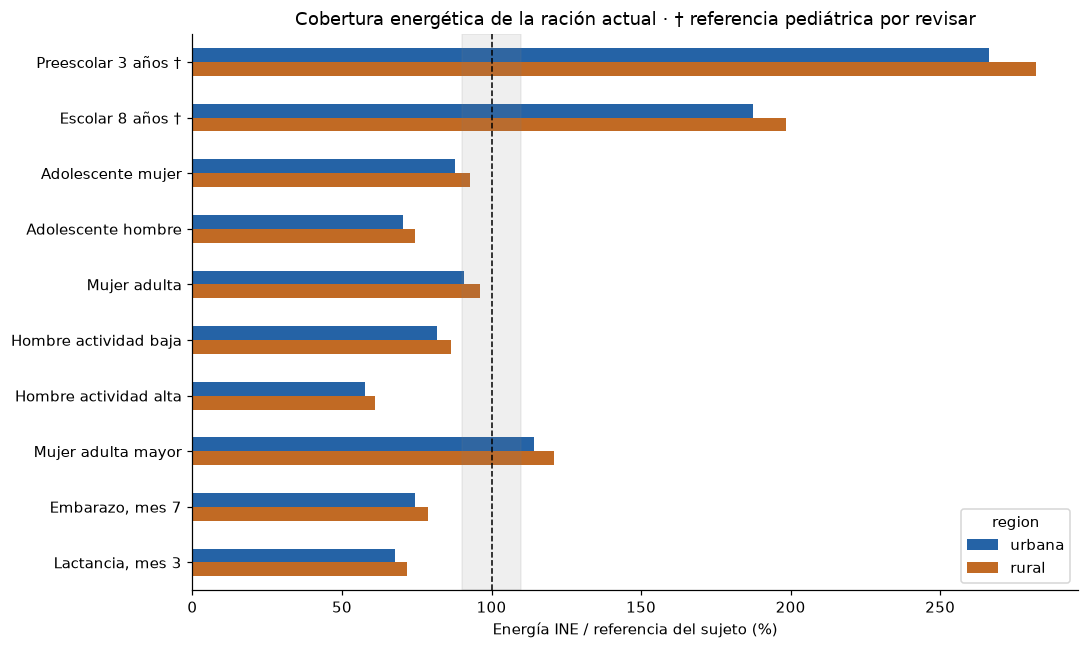

In [ ]:
actual = resumen.loc[resumen['escenario'] == 'Ración actual'].copy()
display(actual[['persona', 'region', 'costo_diario_q', 'costo_periodo_q', 'cobertura_energia_pct',
                'media_cobertura_documentada_pct', 'metas_con_datos', 'metas_totales',
                'bajo_minimo_confirmado', 'maximos_superados_confirmados', 'no_concluyentes']].round(2))

etiquetas = perfiles.set_index('perfil_id')['persona']
energias = actual.pivot(index='perfil_id', columns='region', values='cobertura_energia_pct').reindex(etiquetas.index)
energias.index = etiquetas
ax = energias[['urbana', 'rural']].plot.barh(figsize=(10, 6), color=[COLORES['urbana'], COLORES['rural']])
ax.axvspan(100 * (1 - TOLERANCIA_ENERGIA), 100 * (1 + TOLERANCIA_ENERGIA), color='gray', alpha=0.12)
ax.axvline(100, color='black', linestyle='--', linewidth=1)
ax.set(xlabel='Energía INE / referencia del sujeto (%)', ylabel='',
       title='Cobertura energética de la ración actual · † referencia pediátrica por revisar')
ax.invert_yaxis()
plt.tight_layout()
if EXPORTAR:
    ax.figure.savefig(salida / '02_cobertura_energia.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Cobertura por nutriente y límites

Los mapas usan la ración actual y un conjunto editable de nutrientes. El color se satura a 150 % para facilitar lectura; las cifras y tablas mantienen el valor real. Un asterisco `*` indica datos incompletos: se trata de cobertura **documentada**, no de cobertura total. Una celda gris no tiene dato o referencia positiva.

Azúcares, grasas saturadas y colesterol tienen límites máximos, por lo que se muestran por separado como uso del máximo; no se exige llegar a 100 % de esos límites.

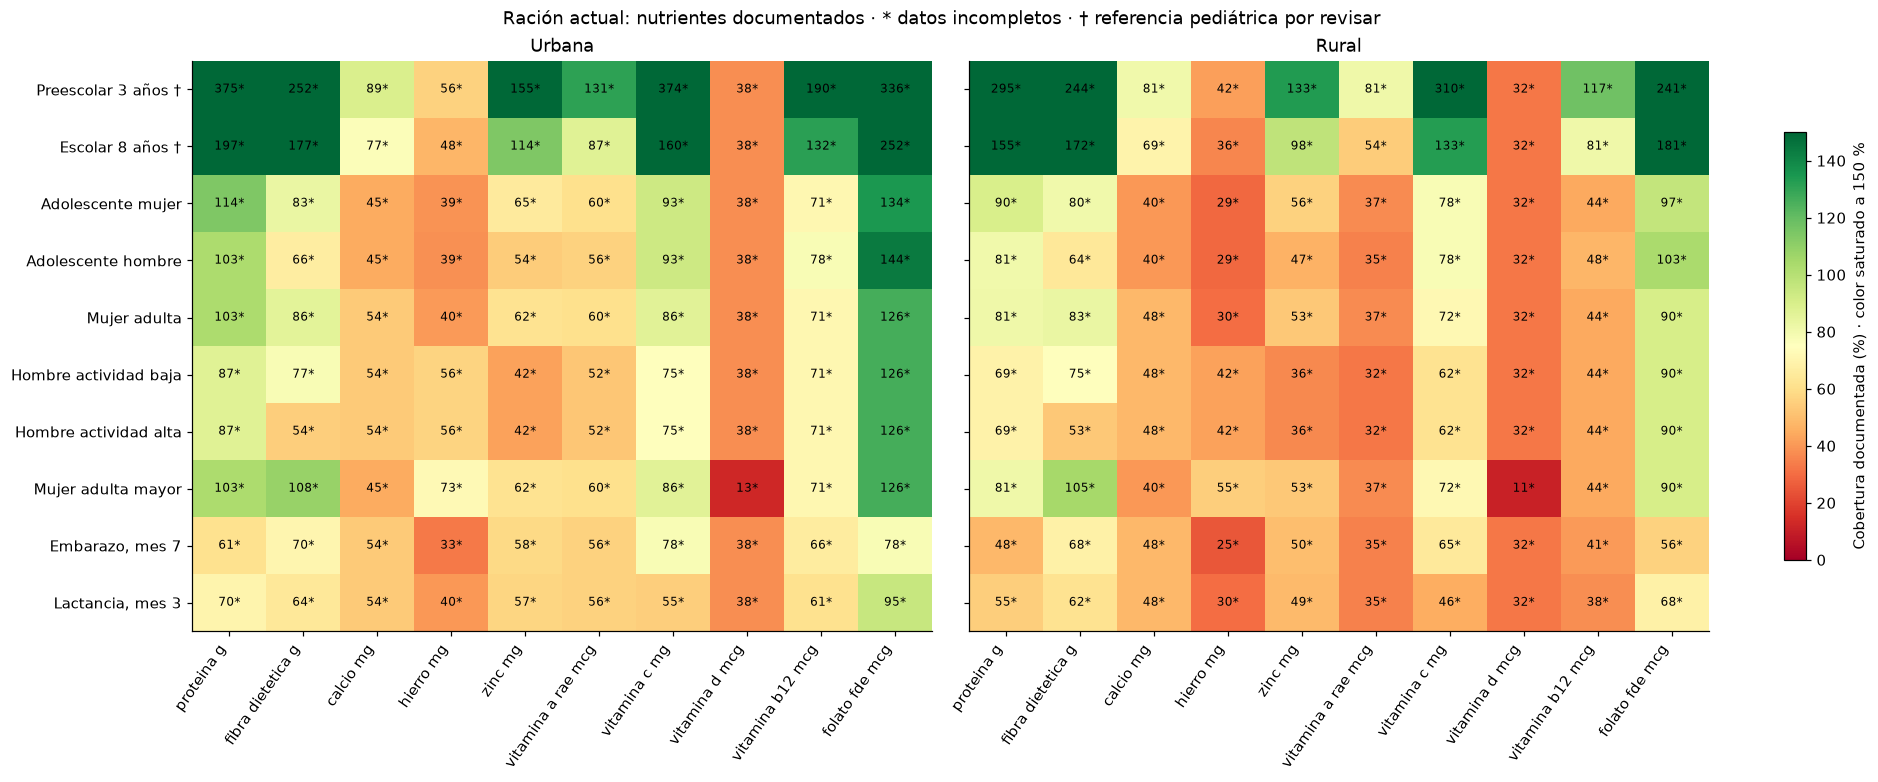

In [ ]:
NUTRIENTES_GRAFICO = ['proteina_g', 'fibra_dietetica_g', 'calcio_mg', 'hierro_mg', 'zinc_mg',
                     'vitamina_a_rae_mcg', 'vitamina_c_mg', 'vitamina_d_mcg', 'vitamina_b12_mcg', 'folato_fde_mcg']
fig, axes = plt.subplots(1, 2, figsize=(17, 7), sharey=True, layout='constrained')
cmap = plt.get_cmap('RdYlGn').copy()
cmap.set_bad('#dddddd')
for ax, region in zip(axes, ['urbana', 'rural']):
    sub = cobertura.loc[(cobertura['region'] == region) & (cobertura['escenario'] == 'Ración actual')]
    matriz = sub.pivot(index='perfil_id', columns='nutriente', values='cobertura_documentada_pct').reindex(
        index=etiquetas.index, columns=NUTRIENTES_GRAFICO)
    completo = sub.pivot(index='perfil_id', columns='nutriente', values='datos_completos').reindex_like(matriz)
    im = ax.imshow(matriz.to_numpy(dtype=float), vmin=0, vmax=150, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(matriz.columns)), [n.replace('_', ' ') for n in matriz.columns], rotation=55, ha='right')
    ax.set_yticks(range(len(etiquetas)), etiquetas)
    ax.set_title(region.capitalize())
    for i in range(len(matriz)):
        for j in range(len(matriz.columns)):
            valor = matriz.iloc[i, j]
            if pd.notna(valor):
                ax.text(j, i, f'{valor:.0f}' + ('' if completo.iloc[i, j] else '*'), ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=axes, label='Cobertura documentada (%) · color saturado a 150 %', shrink=0.75)
fig.suptitle('Ración actual: nutrientes documentados · * datos incompletos · † referencia pediátrica por revisar')
if EXPORTAR:
    fig.savefig(salida / '03_mapa_nutrientes.png', dpi=180, bbox_inches='tight')
plt.show()

In [ ]:
# Cambia el ID para inspeccionar otro sujeto; los IDs evitan confundir nombres repetidos.
PERFIL_DETALLE = 5
ESCENARIO_DETALLE = 'Ración actual'
detalle = cobertura.loc[(cobertura['perfil_id'] == PERFIL_DETALLE) & (cobertura['escenario'] == ESCENARIO_DETALLE)]
display(detalle[['region', 'nutriente', 'unidad', 'aporte_documentado', 'meta', 'minimo', 'maximo',
                'cobertura_documentada_pct', 'uso_maximo_documentado_pct', 'productos_sin_dato', 'estado']].round(2))
display(Markdown('**Incumplimientos confirmados de los máximos del modelo (ración actual)**'))
excesos = cobertura.loc[(cobertura['escenario'] == 'Ración actual') & cobertura['estado'].str.startswith('Supera máximo')]
display(excesos[['persona', 'region', 'nutriente', 'aporte_documentado', 'maximo',
                'exceso_confirmado_minimo', 'datos_completos']].round(2))

,region,nutriente,unidad,aporte_documentado,meta,minimo,maximo,cobertura_documentada_pct,uso_maximo_documentado_pct,productos_sin_dato,estado
512,rural,energia_kcal,kcal,2172.00,2261.93,2035.73,2488.12,96.02,87.29,0,Cumple referencias
513,rural,proteina_g,g,49.99,61.60,61.60,NaN,81.16,NaN,6,No concluyente: datos parciales
514,rural,carbohidratos_g,g,298.13,311.02,311.02,NaN,95.86,NaN,6,No concluyente: datos parciales
515,rural,azucares_g,g,75.59,NaN,NaN,56.55,NaN,133.67,6,Supera máximo aun con datos parciales
516,rural,fibra_dietetica_g,g,22.56,27.14,27.14,NaN,83.10,NaN,6,No concluyente: datos parciales
...,...,...,...,...,...,...,...,...,...,...,...
603,urbana,cobre_mg,mg,1.11,0.90,0.90,10.00,123.83,11.14,4,Mínimo cubierto; máximo no evaluable
604,urbana,zinc_mg,mg,9.00,14.60,14.60,NaN,61.67,NaN,4,No concluyente: datos parciales
605,urbana,potasio_mg,mg,2085.37,4700.00,4700.00,NaN,44.37,NaN,4,No concluyente: datos parciales
606,urbana,sodio_mg,mg,2989.09,1500.00,1500.00,2000.00,199.27,149.45,4,Supera máximo aun con datos parciales


**Incumplimientos confirmados de los máximos del modelo (ración actual)**

,persona,region,nutriente,aporte_documentado,maximo,exceso_confirmado_minimo,datos_completos
0,Preescolar 3 años †,rural,energia_kcal,2172.00,847.34,1324.66,True
3,Preescolar 3 años †,rural,azucares_g,75.59,19.26,56.33,False
5,Preescolar 3 años †,rural,grasa_total_g,38.95,29.96,8.99,False
6,Preescolar 3 años †,rural,ag_sat_g,9.15,6.85,2.30,False
7,Preescolar 3 años †,rural,ag_poli_g,13.05,9.41,3.63,False
...,...,...,...,...,...,...,...
1118,"Embarazo, mes 7",urbana,sodio_mg,2989.09,2000.00,989.09,False
1182,"Lactancia, mes 3",rural,sodio_mg,3391.61,2000.00,1391.61,False
1219,"Lactancia, mes 3",urbana,azucares_g,77.60,75.76,1.83,False
1224,"Lactancia, mes 3",urbana,colesterol_mg,303.30,300.00,3.30,False


## 6. Ajustar energía manteniendo las proporciones

Para cada sujeto y área: `factor = energía requerida / energía INE de la CBA`. Se multiplican todos los gramos, aportes y costos por ese factor. Así se separa el efecto de **cantidad total** del de **composición**; alcanzar la energía no garantiza cubrir los demás nutrientes ni respetar sus máximos.

Este escenario es una comparación matemática y no una propuesta de menú: permite raciones fraccionarias, mantiene todos los productos y supone costos lineales. Los resultados pediátricos heredan la limitación del evaluador.

,persona,region,factor_racion,costo_diario_q,costo_periodo_q,cobertura_energia_pct,media_cobertura_documentada_pct,maximos_superados_confirmados,no_concluyentes
1,Preescolar 3 años †,rural,0.35,8.68,260.37,100.0,67.00,2,23
3,Preescolar 3 años †,urbana,0.38,11.89,356.63,100.0,76.83,2,21
5,Escolar 8 años †,rural,0.50,12.33,370.01,100.0,67.65,2,28
7,Escolar 8 años †,urbana,0.53,16.89,506.79,100.0,78.27,2,21
9,Adolescente mujer,rural,1.08,26.32,789.70,100.0,75.83,2,24
11,Adolescente mujer,urbana,1.14,36.05,1081.62,100.0,85.18,3,18
13,Adolescente hombre,rural,1.34,32.89,986.68,100.0,80.94,2,21
15,Adolescente hombre,urbana,1.42,45.05,1351.42,100.0,89.27,3,16
17,Mujer adulta,rural,1.04,25.49,764.56,100.0,75.51,2,25
19,Mujer adulta,urbana,1.10,34.91,1047.19,100.0,85.44,3,19


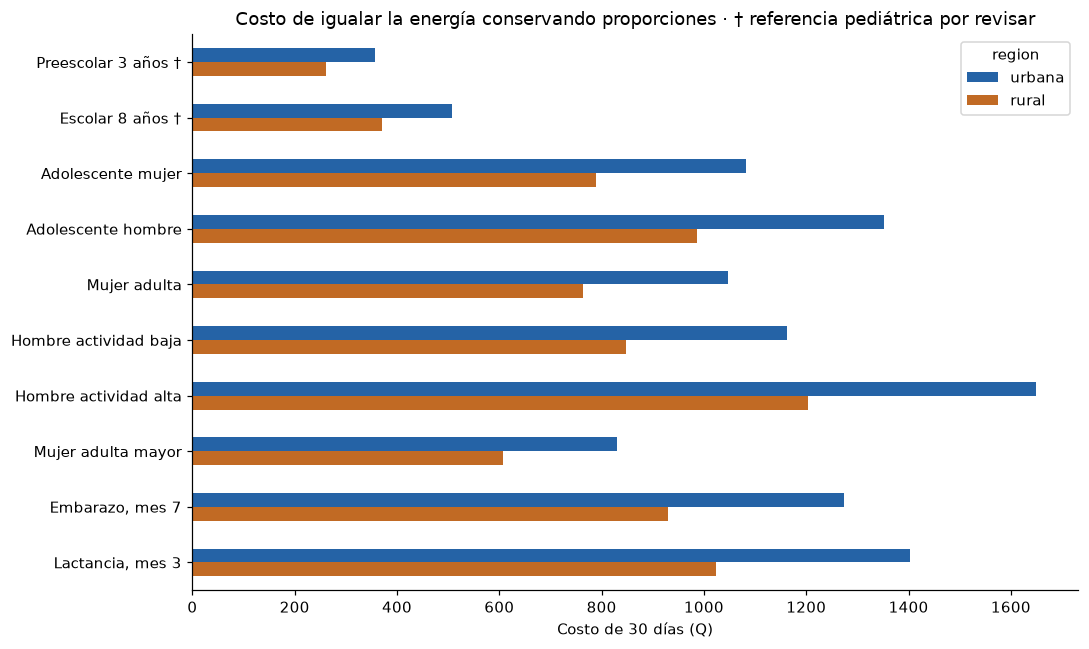

costo_periodo_q_rural_menos_urbana  \
perfil_id persona               escenario                                                
1         Preescolar 3 años †   Ajustada a energía                              -96.25   
                                Ración actual                                  -215.84   
2         Escolar 8 años †      Ajustada a energía                             -136.78   
                                Ración actual                                  -215.84   
3         Adolescente mujer     Ajustada a energía                             -291.93   
                                Ración actual                                  -215.84   
4         Adolescente hombre    Ajustada a energía                             -364.74   
                                Ración actual                                  -215.84   
5         Mujer adulta          Ajustada a energía                             -282.63   
                                Ración actual                                  -215.84   
6         Hombre actividad baja Ajustada a energía                             -313.52   
                                Ración actual                                  -215.84   
7         Hombre actividad alta Ajustada a energía                             -444.99   
                                Ración actual                                  -215.84   
8         Mujer adulta mayor    Ajustada a energía                             -224.28   
                                Ración actual                                  -215.84   
9         Embarazo, mes 7       Ajustada a energía                             -343.97   
                                Ración actual                                  -215.84   
10        Lactancia, mes 3      Ajustada a energía                             -378.68   
                                Ración actual                                  -215.84   

                                                    cobertura_energia_pct_rural_menos_urbana  \
perfil_id persona               escenario                                                      
1         Preescolar 3 años †   Ajustada a energía                                      0.00   
                                Ración actual                                          15.58   
2         Escolar 8 años †      Ajustada a energía                                      0.00   
                                Ración actual                                          10.96   
3         Adolescente mujer     Ajustada a energía                                      0.00   
                                Ración actual                                           5.14   
4         Adolescente hombre    Ajustada a energía                                      0.00   
                                Ración actual                                           4.11   
5         Mujer adulta          Ajustada a energía                                      0.00   
                                Ración actual                                           5.31   
6         Hombre actividad baja Ajustada a energía                                      0.00   
                                Ración actual                                           4.78   
7         Hombre actividad alta Ajustada a energía                                      0.00   
                                Ración actual                                           3.37   
8         Mujer adulta mayor    Ajustada a energía                                      0.00   
                                Ración actual                                           6.69   
9         Embarazo, mes 7       Ajustada a energía                                      0.00   
                                Ración actual                                           4.36   
10        Lactancia, mes 3      Ajustada a energía                                      0.00   
                                Ración actual          

In [ ]:
ajustada = resumen.loc[resumen['escenario'] == 'Ajustada a energía'].copy()
display(ajustada[['persona', 'region', 'factor_racion', 'costo_diario_q', 'costo_periodo_q',
                  'cobertura_energia_pct', 'media_cobertura_documentada_pct',
                  'maximos_superados_confirmados', 'no_concluyentes']].round(2))

costos = ajustada.pivot(index='perfil_id', columns='region', values='costo_periodo_q').reindex(etiquetas.index)
costos.index = etiquetas
ax = costos[['urbana', 'rural']].plot.barh(figsize=(10, 6), color=[COLORES['urbana'], COLORES['rural']])
ax.set(xlabel=f'Costo de {DIAS} días (Q)', ylabel='',
       title='Costo de igualar la energía conservando proporciones · † referencia pediátrica por revisar')
ax.invert_yaxis()
plt.tight_layout()
if EXPORTAR:
    ax.figure.savefig(salida / '04_costo_ajustado_energia.png', dpi=180, bbox_inches='tight')
plt.show()

# Diferencias pareadas: rural menos urbana; no se usan precios de un área en la otra.
comparacion = resumen.pivot(index=['perfil_id', 'persona', 'escenario'], columns='region',
                          values=['costo_periodo_q', 'cobertura_energia_pct', 'media_cobertura_documentada_pct'])
diferencias = pd.DataFrame({f'{variable}_rural_menos_urbana': comparacion[(variable, 'rural')] - comparacion[(variable, 'urbana')]
                           for variable in ['costo_periodo_q', 'cobertura_energia_pct', 'media_cobertura_documentada_pct']})
display(diferencias.round(2))

## 7. Alimentos, contribuciones y lectura de resultados

La tabla siguiente permite rastrear la cantidad oficial, la proporción por gramos y la contribución de cada alimento a un nutriente. Para visualizar aportes desconocidos se mantiene `NaN`; la energía por producto publicada por INE está en `canastas['energia_ine_kcal']`.

In [ ]:
REGION_DETALLE = 'rural'
NUTRIENTE_DETALLE = 'hierro_mg'
alimentos_detalle = analisis['aportes_por_alimento'].loc[
    lambda t: (t['region'] == REGION_DETALLE) & (t['nutriente'] == NUTRIENTE_DETALLE)]
alimentos_detalle = alimentos_detalle.merge(
    canastas[['region', 'producto', 'proporcion_gramos_pct', 'costo_diario_q']], on=['region', 'producto'], validate='one_to_one')
display(alimentos_detalle.sort_values('aporte', ascending=False, na_position='last').round(4))

# Cantidades del escenario ajustado: todas las proporciones se conservan.
raciones_ajustadas = ajustada[['perfil_id', 'persona', 'region', 'factor_racion']].merge(canastas, on='region')
raciones_ajustadas['gramos_ajustados_dia'] = raciones_ajustadas['gramos_diarios'] * raciones_ajustadas['factor_racion']
raciones_ajustadas['costo_ajustado_dia_q'] = raciones_ajustadas['costo_diario_q'] * raciones_ajustadas['factor_racion']
display(raciones_ajustadas.loc[raciones_ajustadas['perfil_id'] == PERFIL_DETALLE,
    ['persona', 'region', 'producto', 'proporcion_gramos_pct', 'gramos_ajustados_dia', 'costo_ajustado_dia_q']].round(3))

,region,producto,alimento_id,nombre_incap,nutriente,gramos_diarios,aporte,dato_disponible,proporcion_gramos_pct,costo_diario_q
8,rural,Tortillas frescas,tortillas_de_maiz,"TORTILLA DE MAIZ BLANCO, C/CAL",hierro_mg,305.8934,2.6001,True,22.8710,3.3159
12,rural,"Frijoles negros, secos",frijol,"FRIJOL NEGRO, GRANO SECO",hierro_mg,27.7350,1.3923,True,2.0737,0.4582
6,rural,Pan dulce,pan_dulce,"PAN DULCE, SIMPLE",hierro_mg,27.3670,0.7854,True,2.0462,0.5445
44,rural,Huevos de gallina de granja,huevos_de_gallina,"HUEVO DE GALLINA, ENTERO, CRUDO",hierro_mg,39.3229,0.6056,True,2.9401,1.0668
16,rural,Macuy/Hierba mora/Quilete,hierbas,"HIERBAMORA O MACUY, FRESCO",hierro_mg,6.6955,0.4941,True,0.5006,0.1070
5,rural,Pan francés,pan_frances,PAN FRANCES SIMPLE,hierro_mg,13.3027,0.3605,True,0.9946,0.2724
22,rural,Cebollas,cebolla_blanca_sin_tallo,"CEBOLLA, CABEZA Y TALLOS",hierro_mg,22.0109,0.3127,True,1.6457,0.3394
3,rural,Harina de maíz,harina_de_maiz,"HARINA DE MAIZ BLANCO, GRANO ENTERO",hierro_mg,12.4427,0.2961,True,0.9303,0.1789
50,rural,Sopas instantáneas (Vaso y bolsa),sopas_instantaneas_en_vaso,"SOPA DESHIDRATADA, FIDEO RAMEN, CUALQUIER SABOR",hierro_mg,5.5111,0.2265,True,0.4121,0.4707
40,rural,Carne de pollo amarillo,carne_de_pollo_amarillo,"POLLO, CARNE C/PIEL, CRUDA",hierro_mg,32.6779,0.2000,True,2.4433,1.0509


,persona,region,producto,proporcion_gramos_pct,gramos_ajustados_dia,costo_ajustado_dia_q
504,Mujer adulta,rural,Arroz corriente,1.274,17.750,0.330
505,Mujer adulta,rural,Arroz precocido,0.234,3.255,0.065
506,Mujer adulta,rural,Maíz blanco,5.899,82.170,0.425
507,Mujer adulta,rural,Harina de maíz,0.930,12.958,0.186
508,Mujer adulta,rural,Harina para atoles (incluye Incaparina),0.348,4.847,0.121
...,...,...,...,...,...,...
625,Mujer adulta,urbana,Desayuno o cena continental (bebida y dos acompañamientos elaborados),1.462,28.342,1.666
626,Mujer adulta,urbana,"Almuerzo o cena simple (bebida, carne de pollo y acompañamiento) excluye gaseosa",3.867,74.986,4.414
627,Mujer adulta,urbana,Tamales y paches,1.058,20.511,0.650
628,Mujer adulta,urbana,Piezas de pollo individual o entero (sin acompañamiento),0.804,15.599,0.901


In [ ]:
lineas = [f'### Hallazgos calculados para {periodo_analizado}']
for fila in auditoria.itertuples():
    lineas.append(f'- **{fila.region.capitalize()}**: {fila.productos} productos, '
                  f'Q {fila.costo_diario_q:.2f}/persona/día, Q {fila.costo_periodo_q:.2f}/{DIAS} días '
                  f'y {fila.energia_ine_kcal:.0f} kcal/día publicadas por INE. '
                  f'{fila.productos_emparejados} productos tienen composición asociada.')
# Las conclusiones energéticas se restringen a perfiles sin la limitación pediátrica identificada.
validos = perfiles.loc[perfiles['advertencia_modelo'] == '', 'perfil_id']
for region in ['urbana', 'rural']:
    sub = actual.loc[(actual['region'] == region) & actual['perfil_id'].isin(validos)]
    bajo = sub.loc[sub['cobertura_energia_pct'] < 100 * (1 - TOLERANCIA_ENERGIA), 'persona']
    lineas.append(f'- **{region.capitalize()}**, energía por debajo de la banda del modelo en: '
                  + (', '.join(bajo) if len(bajo) else 'ninguno de los perfiles adultos/adolescentes configurados') + '.')
lineas.append('- Para los demás nutrientes, revisa la columna **estado**: una cobertura documentada baja '
              'con productos faltantes no permite concluir que la CBA completa incumple. '
              'La media de coberturas no acredita suficiencia global.')
display(Markdown('\n'.join(lineas)))

### Hallazgos calculados para 2026-08
- **Rural**: 60 productos, Q 24.47/persona/día, Q 734.16/30 días y 2172 kcal/día publicadas por INE. 54 productos tienen composición asociada.
- **Urbana**: 66 productos, Q 31.67/persona/día, Q 950.00/30 días y 2052 kcal/día publicadas por INE. 62 productos tienen composición asociada.
- **Urbana**, energía por debajo de la banda del modelo en: Adolescente mujer, Adolescente hombre, Hombre actividad baja, Hombre actividad alta, Embarazo, mes 7, Lactancia, mes 3.
- **Rural**, energía por debajo de la banda del modelo en: Adolescente hombre, Hombre actividad baja, Hombre actividad alta, Embarazo, mes 7, Lactancia, mes 3.
- Para los demás nutrientes, revisa la columna **estado**: una cobertura documentada baja con productos faltantes no permite concluir que la CBA completa incumple. La media de coberturas no acredita suficiencia global.

## 8. Exportación y reproducibilidad

Las salidas se guardan en `data/processed/analisis_cobertura_cba/<año-mes>/`: tablas CSV, parámetros y figuras PNG. Los CSV mantienen precisión numérica; las tablas visibles redondean solo para presentación. Cambiar perfiles, mes, equivalencias o supuestos requiere ejecutar nuevamente todas las celdas.

Para completar la evaluación, revisa primero `sin_equivalencia` y los datos faltantes por nutriente. Las comidas preparadas requieren una composición o receta documentada. Las equivalencias manuales deben tener una justificación; el precio y los gramos seguirán siendo los originales del Excel.

In [ ]:
if EXPORTAR:
    tablas_exportar = {**analisis, 'sin_equivalencia': sin_equivalencia,
                       'diferencias_areas': diferencias.reset_index(), 'raciones_ajustadas': raciones_ajustadas}
    for nombre, tabla in tablas_exportar.items():
        tabla.to_csv(salida / f'{nombre}.csv', index=False, encoding='utf-8-sig')
    parametros = dict(periodo=periodo_analizado, dias=DIAS, sujetos=SUJETOS, hierro=HIERRO,
                      tolerancia_energia=TOLERANCIA_ENERGIA, aplicar_fraccion_comestible=APLICAR_FRACCION_COMESTIBLE,
                      exposicion_solar_suficiente=EXPOSICION_SOLAR_SUFICIENTE, equivalencias=EQUIVALENCIAS,
                      catalogo=str(CATALOGO.relative_to(PROJECT_ROOT)),
                      fuentes=canastas[['region', 'fuente']].drop_duplicates().to_dict('records'))
    (salida / 'parametros.json').write_text(json.dumps(parametros, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'Exportados {len(tablas_exportar)} CSV, 4 figuras y parámetros en: {salida}')

Exportados 10 CSV, 4 figuras y parámetros en: C:\Users\lp109\Projects\canasta-inteligente-gt\data\processed\analisis_cobertura_cba\2026-08
